# Ensemble & Test KL Divergence Evaluation
Loads multiple `submission.csv` files, averages their predicted probability distributions, and evaluates KL Divergence against `confident_test.csv` ground truth.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# ── Configuration ─────────────────────────────────────────────────────────
# Path to confident_test.csv (ground truth)
CONFIDENT_TEST_PATH = Path("/home/littl/data/data/confident_test.csv")

# List all submission CSV paths to ensemble
SUBMISSION_PATHS = [
    Path("/home/littl/ECE247A_Final_Project/ensemble/submission_baseline_AL.csv"),
    Path("/home/littl/ECE247A_Final_Project/ensemble/submission_spectrogram_gru_AL.csv"),
    Path("/home/littl/ECE247A_Final_Project/ensemble/JZ_conv1d_biGRU_confident_test_predictions_t12_ensemble.csv"),
    Path("/home/littl/ECE247A_Final_Project/ensemble/scalogram-0.9883_GC.csv"),
    Path("/home/littl/ECE247A_Final_Project/ensemble/spectrogram-0.8538_GC.csv"),
    
    # add more as needed
]

# Class columns — must match submission file column names
CLASS_NAMES  = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
TARGET_COLS  = [x.lower() + "_vote" for x in CLASS_NAMES]

# HQ consensus threshold (matches training/eval code)
HQ_THRESHOLD = 0.9

print(f"Target columns: {TARGET_COLS}")

Target columns: ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']


In [2]:
# ── Load ground truth from confident_test.csv ─────────────────────────────
test_df = pd.read_csv(CONFIDENT_TEST_PATH)

vote_cols = ["seizure_vote", "lpd_vote", "gpd_vote", "lrda_vote", "grda_vote", "other_vote"]
test_votes = test_df[vote_cols].values.astype(np.float64)
vote_sums  = test_votes.sum(axis=1, keepdims=True).clip(1.0)
targets    = test_votes / vote_sums          # soft label ground truth
consensus  = targets.max(axis=1)             # per-sample max agreement

print(f"Test samples  : {len(test_df)}")
print(f"HQ samples    : {(consensus >= HQ_THRESHOLD).sum()} (consensus >= {HQ_THRESHOLD})")
print(f"Consensus     : min={consensus.min():.3f}  median={np.median(consensus):.3f}  max={consensus.max():.3f}")

Test samples  : 6621
HQ samples    : 6064 (consensus >= 0.9)
Consensus     : min=0.700  median=1.000  max=1.000


In [3]:
# ── Load and validate submission files ────────────────────────────────────
all_preds = []

for path in SUBMISSION_PATHS:
    sub = pd.read_csv(path)
    assert "eeg_id" in sub.columns, f"Missing eeg_id in {path.name}"
    for col in TARGET_COLS:
        assert col in sub.columns, f"Missing column {col} in {path.name}"

    # Align to test_df order by eeg_id
    sub = sub.set_index("eeg_id").reindex(test_df["eeg_id"]).reset_index()
    assert not sub[TARGET_COLS].isnull().any().any(), f"NaNs after alignment in {path.name} — eeg_id mismatch?"

    preds = sub[TARGET_COLS].values.astype(np.float64)
    all_preds.append(preds)
    print(f"Loaded {path.name:40s} | shape={preds.shape} | row_sum min={preds.sum(axis=1).min():.4f}")

print(f"\nTotal submissions loaded: {len(all_preds)}")

Loaded submission_baseline_AL.csv               | shape=(6621, 6) | row_sum min=1.0000
Loaded submission_spectrogram_gru_AL.csv        | shape=(6621, 6) | row_sum min=1.0000
Loaded JZ_conv1d_biGRU_confident_test_predictions_t12_ensemble.csv | shape=(6621, 6) | row_sum min=1.0000
Loaded scalogram-0.9883_GC.csv                  | shape=(6621, 6) | row_sum min=1.0000
Loaded spectrogram-0.8538_GC.csv                | shape=(6621, 6) | row_sum min=1.0000

Total submissions loaded: 5


In [4]:
# ── Ensemble: average then renormalize ────────────────────────────────────
# ensemble = np.mean(all_preds, axis=0)                          # average across submissions
# ensemble = ensemble / ensemble.sum(axis=1, keepdims=True)      # renormalize to valid simplex

# ── Ensemble: weighted average then renormalize ───────────────────────────
# Weights correspond to each submission in SUBMISSION_PATHS order
# e.g. [1.0, 2.0] gives the second submission twice the weight of the first
WEIGHTS = [1.0, 1.0, 1.0, 1.0, 1.0]  # change these

assert len(WEIGHTS) == len(all_preds), "WEIGHTS length must match number of submissions"
w = np.array(WEIGHTS, dtype=np.float64) / sum(WEIGHTS)        # normalize weights to sum to 1
ensemble = np.sum([w[i] * all_preds[i] for i in range(len(all_preds))], axis=0)
ensemble = ensemble / ensemble.sum(axis=1, keepdims=True)      # renormalize to valid simplex

print(f"Weights applied: {dict(zip([p.name for p in SUBMISSION_PATHS], WEIGHTS))}")

print(f"Ensemble shape : {ensemble.shape}")
print(f"Row sum check  : min={ensemble.sum(axis=1).min():.6f}  max={ensemble.sum(axis=1).max():.6f}")

Weights applied: {'submission_baseline_AL.csv': 1.0, 'submission_spectrogram_gru_AL.csv': 1.0, 'JZ_conv1d_biGRU_confident_test_predictions_t12_ensemble.csv': 1.0, 'scalogram-0.9883_GC.csv': 1.0, 'spectrogram-0.8538_GC.csv': 1.0}
Ensemble shape : (6621, 6)
Row sum check  : min=1.000000  max=1.000000


In [5]:
# ── KL Divergence evaluation ───────────────────────────────────────────────
# KL(targets || ensemble): matches the convention used in training/evaluation code
kl_per_sample = (targets * np.log(targets.clip(1e-8) / ensemble.clip(1e-8))).sum(axis=1)

hq_mask = consensus >= HQ_THRESHOLD

kl_all = kl_per_sample.mean()
kl_hq  = kl_per_sample[hq_mask].mean() if hq_mask.any() else float("nan")

print("\n" + "="*50)
print("ENSEMBLE TEST KL DIVERGENCE")
print("="*50)
print(f"  ALL samples : {kl_all:.4f}  (n={len(kl_per_sample)})")
print(f"  HQ (>={HQ_THRESHOLD}) : {kl_hq:.4f}  (n={hq_mask.sum()}/{len(hq_mask)})")


ENSEMBLE TEST KL DIVERGENCE
  ALL samples : 0.6786  (n=6621)
  HQ (>=0.9) : 0.6925  (n=6064/6621)


In [6]:
# ── Per-submission KL for comparison ──────────────────────────────────────
print(f"{'Submission':<45} {'KL ALL':>10} {'KL HQ':>10}")
print("-" * 67)

for path, preds in zip(SUBMISSION_PATHS, all_preds):
    preds_norm = preds / preds.sum(axis=1, keepdims=True)
    kl = (targets * np.log(targets.clip(1e-8) / preds_norm.clip(1e-8))).sum(axis=1)
    print(f"{path.name:<45} {kl.mean():>10.4f} {kl[hq_mask].mean():>10.4f}")

print("-" * 67)
print(f"{'ENSEMBLE':<45} {kl_all:>10.4f} {kl_hq:>10.4f}")

Submission                                        KL ALL      KL HQ
-------------------------------------------------------------------
submission_baseline_AL.csv                        0.8098     0.8281
submission_spectrogram_gru_AL.csv                 0.7569     0.7637
JZ_conv1d_biGRU_confident_test_predictions_t12_ensemble.csv     0.8421     0.8682
scalogram-0.9883_GC.csv                           0.9883     0.9748
spectrogram-0.8538_GC.csv                         0.8541     0.8668
-------------------------------------------------------------------
ENSEMBLE                                          0.6786     0.6925


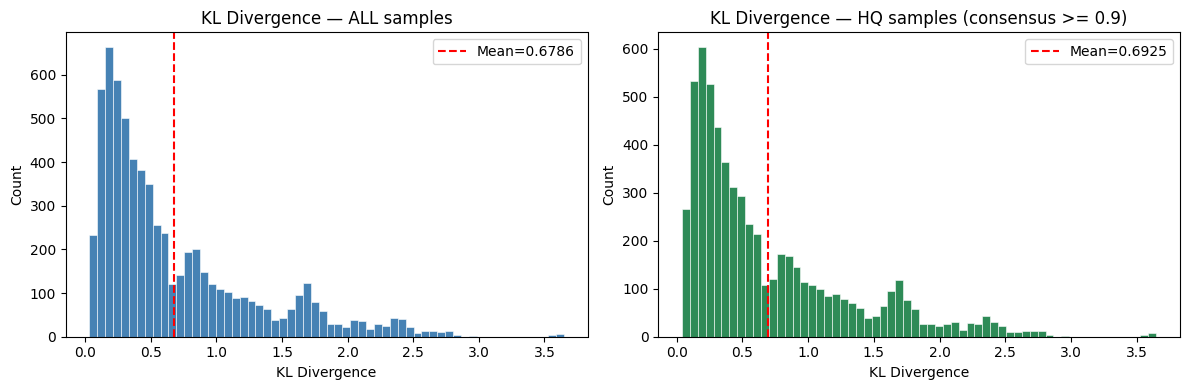

In [7]:
# ── KL distribution plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All samples
axes[0].hist(kl_per_sample, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(kl_all, color="red", linestyle="--", label=f"Mean={kl_all:.4f}")
axes[0].set_title("KL Divergence — ALL samples")
axes[0].set_xlabel("KL Divergence"); axes[0].set_ylabel("Count")
axes[0].legend()

# HQ samples
axes[1].hist(kl_per_sample[hq_mask], bins=60, color="seagreen", edgecolor="white", linewidth=0.4)
axes[1].axvline(kl_hq, color="red", linestyle="--", label=f"Mean={kl_hq:.4f}")
axes[1].set_title(f"KL Divergence — HQ samples (consensus >= {HQ_THRESHOLD})")
axes[1].set_xlabel("KL Divergence"); axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# ── Save ensemble submission ───────────────────────────────────────────────
OUTPUT_PATH = Path("submission_ensemble.csv")

pred_df = test_df[["eeg_id"]].copy()
pred_df[TARGET_COLS] = ensemble.tolist()
pred_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}  ({len(pred_df)} rows)")
print(pred_df.head())

Saved: submission_ensemble.csv  (6621 rows)
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  4245882082      0.334278  0.014433  0.017033   0.032437   0.257182   
1  2857590162      0.205914  0.052869  0.072881   0.086777   0.193832   
2  2857590162      0.129003  0.053162  0.068322   0.088407   0.204885   
3  2857590162      0.107526  0.052443  0.049435   0.093663   0.223014   
4  3523834378      0.877724  0.032023  0.013133   0.010857   0.017454   

   other_vote  
0    0.344637  
1    0.387727  
2    0.456220  
3    0.473919  
4    0.048810  
